# LeetCode #39: Combination Sum

https://leetcode.com/problems/combination-sum/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force** | $O(N^{T/M})$ | $O(T/M)$ |
| **Backtracking (DFS) + Sort & Prune** | $O(N^{T/M})$ | $O(T/M)$ |

---

## Understanding the Methods

### Brute Force
Recursively try every candidate at every position without any early exit. The same candidates are re-explored in different orderings, producing duplicate combinations that then need de-duplication. No pruning means the full search space is traversed even when a branch is provably over-target.

### Optimal: Backtracking (DFS) + Sort & Prune ★
Sort candidates once, then DFS starting from index `start` — each recursive call only considers candidates at or after `start`, which eliminates duplicate orderings without a set. Add a **pruning guard**: if the current candidate already exceeds the remaining target, break immediately (all further candidates are ≥ current, so none can help). Each number can be reused by recursing with the same `start` index.

**Why this is better than Brute Force:** Sorting enables the early-break prune that cuts entire subtrees the moment a candidate exceeds the remainder; fixing the `start` index eliminates duplicate orderings entirely, so no de-duplication pass is needed.

**Constraints:**
* 1 <= candidates.length <= 30
* 2 <= candidates[i] <= 40
* All elements of candidates are distinct
* 1 <= target <= 40

## Solutions

### C#

In [ ]:
public class Solution {
    public IList<IList<int>> CombinationSum(int[] candidates, int target) {
        var result = new List<IList<int>>();
        Array.Sort(candidates);
        Backtrack(candidates, target, 0, new List<int>(), result);
        return result;
    }

    private void Backtrack(int[] candidates, int remain, int start, List<int> path, IList<IList<int>> result) {
        if (remain == 0) { result.Add(new List<int>(path)); return; }
        for (int i = start; i < candidates.Length; i++) {
            // Sorted array lets us prune all further candidates once one exceeds the remainder
            if (candidates[i] > remain) break;
            path.Add(candidates[i]);
            // Pass i (not i+1) to allow reuse of the same candidate
            Backtrack(candidates, remain - candidates[i], i, path, result);
            path.RemoveAt(path.Count - 1);
        }
    }
}

### Python

In [ ]:
class Solution:
    def combinationSum(self, candidates: list[int], target: int) -> list[list[int]]:
        candidates.sort()
        result = []

        def backtrack(start: int, path: list[int], remain: int) -> None:
            if remain == 0:
                result.append(list(path))
                return
            for i in range(start, len(candidates)):
                # Sorted array lets us prune all further candidates once one exceeds the remainder
                if candidates[i] > remain:
                    break
                path.append(candidates[i])
                # Pass i (not i+1) to allow reuse of the same candidate
                backtrack(i, path, remain - candidates[i])
                path.pop()

        backtrack(0, [], target)
        return result

### Go

In [ ]:
func combinationSum(candidates []int, target int) [][]int {
    sort.Ints(candidates)
    result := [][]int{}
    var backtrack func(start, remain int, path []int)
    backtrack = func(start, remain int, path []int) {
        if remain == 0 {
            combo := make([]int, len(path))
            copy(combo, path)
            result = append(result, combo)
            return
        }
        for i := start; i < len(candidates); i++ {
            // Sorted array lets us prune all further candidates once one exceeds the remainder
            if candidates[i] > remain {
                break
            }
            // Pass i (not i+1) to allow reuse of the same candidate
            backtrack(i, remain-candidates[i], append(path, candidates[i]))
        }
    }
    backtrack(0, target, []int{})
    return result
}

### Rust

In [ ]:
impl Solution {
    pub fn combination_sum(mut candidates: Vec<i32>, target: i32) -> Vec<Vec<i32>> {
        candidates.sort();
        let mut result = Vec::new();
        Self::backtrack(&candidates, target, 0, &mut Vec::new(), &mut result);
        result
    }

    fn backtrack(candidates: &[i32], remain: i32, start: usize, path: &mut Vec<i32>, result: &mut Vec<Vec<i32>>) {
        if remain == 0 {
            result.push(path.clone());
            return;
        }
        for i in start..candidates.len() {
            // Sorted array lets us prune all further candidates once one exceeds the remainder
            if candidates[i] > remain {
                break;
            }
            path.push(candidates[i]);
            // Pass i (not i+1) to allow reuse of the same candidate
            Self::backtrack(candidates, remain - candidates[i], i, path, result);
            path.pop();
        }
    }
}

## Example Scenarios

**1. Common Case**
**Input:** candidates = [2, 3, 6, 7], target = 7
After sorting: [2, 3, 6, 7]. DFS explores: 2→2→2→(remain=1, 2>1 break), 2→2→3→(remain=0 ✓ [2,2,3]), 2→3→(remain=2)→2→(remain=0 ✓ [2,3,2]... pruned by start index), 3→(remain=4)→3→(remain=1, 3>1 break), 7→(remain=0 ✓ [7]). Result: [[2,2,3],[7]].

**2. Slightly Complex**
**Input:** candidates = [2, 3, 5], target = 8
Sorted: [2, 3, 5]. Three valid combinations: [2,2,2,2] (four 2s), [2,3,3] (one 2 + two 3s), [3,5] (one 3 + one 5). The `start` index ensures [3,2,3] and [5,3] are never explored — the tree only grows right or downward, never left.

**3. Edge Case: Time Factor**
**Input:** candidates = [2], target = 40 (maximum reuse depth)
Only one candidate, so the DFS is a straight path: 2→4→6→…→40, depth = $T/M = 40/2 = 20$. This is the maximum possible recursion depth given the constraints. The prune never fires because there's only one candidate that always fits until remain=0. Result: [[2,2,…,2]] (twenty 2s).

**4. Edge Case: Space Factor**
**Input:** candidates = [2, 3, 6, 7], target = 40
Maximum target with multi-candidate exploration. Peak stack depth = $\lfloor 40/2 \rfloor = 20$ frames (all-2s path). The `path` list grows to at most depth 20. Each frame stores only `start`, `remain`, and a reference to the shared path — $O(T/M)$ auxiliary space total.

**5. Almost-Impossible but Plausible**
**Input:** candidates = [40], target = 1
The single candidate (40) immediately exceeds the target (1). At the first iteration: `candidates[0]=40 > remain=1` → break. Zero recursive calls made beyond the root. Result: []. The sort+prune short-circuits on the very first candidate, making this the most efficient possible case — $O(1)$ work beyond sorting.

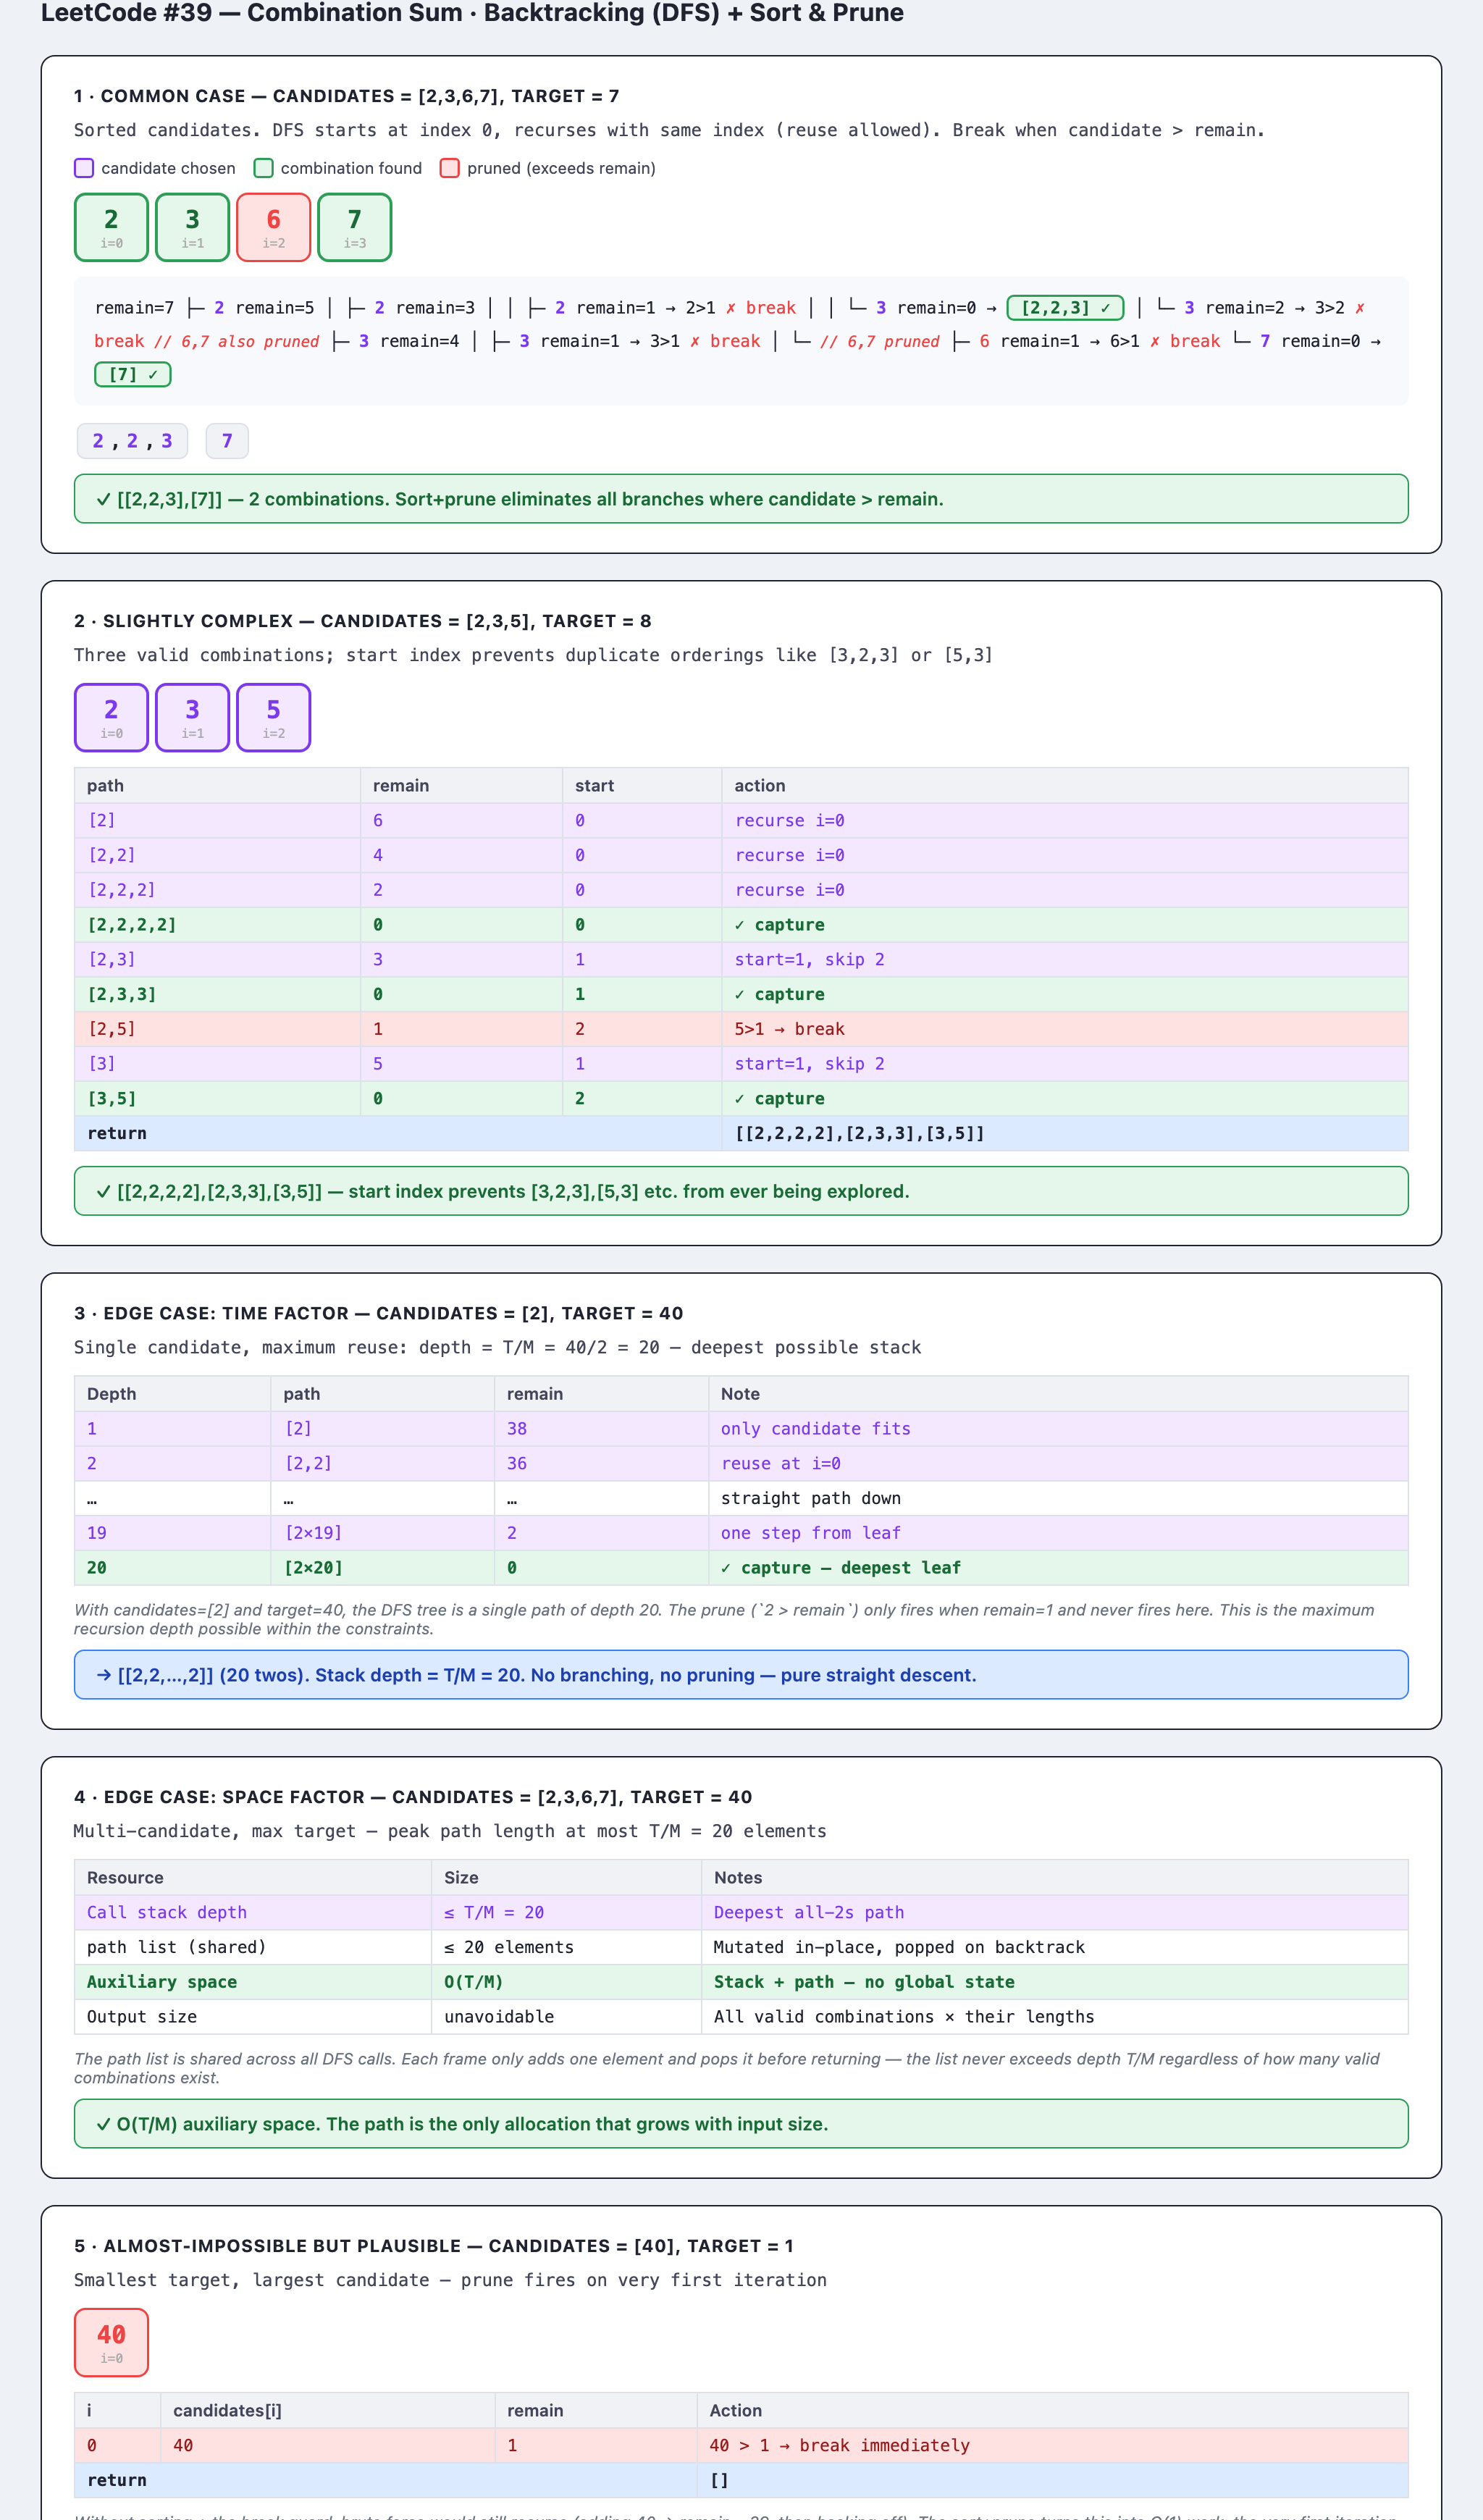